# Импорт библиотек

In [ ]:
import xml.etree.ElementTree as ET
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.patches as patches

# Загрузка датасета

In [2]:
!git clone https://github.com/Shenggan/BCCD_Dataset.git

Cloning into 'BCCD_Dataset'...
remote: Enumerating objects: 800, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 800 (delta 8), reused 6 (delta 6), pack-reused 789 (from 1)
Receiving objects: 100% (800/800), 7.39 MiB | 8.71 MiB/s, done.
Resolving deltas: 100% (379/379), done.


In [3]:
DATASET_DIR = Path("BCCD_Dataset/BCCD")
IMAGES_DIR = DATASET_DIR / "JPEGImages"
ANNOTATIONS_DIR = DATASET_DIR / "Annotations"

In [4]:
print("Папка с изображениями:", IMAGES_DIR.exists())
print("Папка с аннотациями:", ANNOTATIONS_DIR.exists())

Папка с изображениями: True
Папка с аннотациями: True


# EDA

Разберем XML-аннотаций Pascal VOC

In [5]:
def parse_voc_annotation(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    records = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        records.append({
            "filename": filename,
            "image_width": width,
            "image_height": height,
            "class_name": class_name,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_width": xmax - xmin,
            "bbox_height": ymax - ymin,
            "bbox_area": (xmax - xmin) * (ymax - ymin)
        })

    return records

In [6]:
all_records = []

for xml_file in ANNOTATIONS_DIR.glob("*.xml"):
    all_records.extend(parse_voc_annotation(xml_file))

df = pd.DataFrame(all_records)

df.head()

,filename,image_width,image_height,class_name,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area
0,BloodImage_00315.jpg,640,480,RBC,164,261,297,364,133,103,13699
1,BloodImage_00315.jpg,640,480,RBC,15,66,148,169,133,103,13699
2,BloodImage_00315.jpg,640,480,RBC,13,234,132,333,119,99,11781
3,BloodImage_00315.jpg,640,480,RBC,239,3,354,107,115,104,11960
4,BloodImage_00315.jpg,640,480,RBC,542,109,640,214,98,105,10290


Общая структура датасета

In [7]:
num_images = len(list(IMAGES_DIR.glob("*.jpg")))
num_annotations = len(df)
num_classes = df["class_name"].nunique()

In [8]:
print(f"Количество изображений: {num_images}")
print(f"Количество размеченных объектов: {num_annotations}")
print(f"Количество классов: {num_classes}")
print("Классы:", sorted(df["class_name"].unique()))

Количество изображений: 364
Количество размеченных объектов: 4888
Количество классов: 3
Классы: ['Platelets', 'RBC', 'WBC']


Platelets – тромбоциты

RBC – эритроциты

WBC – лейкоциты

Посмотрим распределение объектов по классам

In [9]:
class_counts = df["class_name"].value_counts()
class_counts

class_name
RBC          4155
WBC           372
Platelets     361
Name: count, dtype: int64

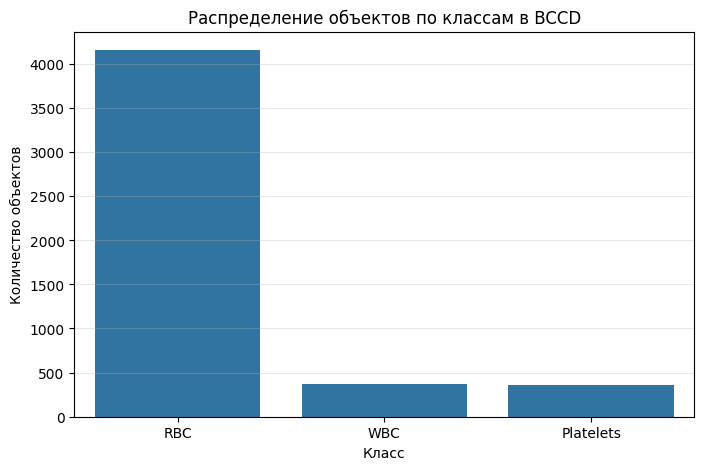

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)
plt.title("Распределение объектов по классам в BCCD")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.grid(axis="y", alpha=0.3)
plt.show()

Видно, что наибольшее количество объектов относится к классу RBC, то есть эритроцитам. Классы WBC и Platelets представлены значительно меньшим числом объектов. Это указывает на выраженный дисбаланс классов, который необходимо учитывать при дальнейшем обучении модели детекции объектов.

Количество объектов на одно изображение

In [11]:
objects_per_image = df.groupby("filename").size()
objects_per_image.describe()

count    364.000000
mean      13.428571
std        4.474335
min        1.000000
25%       11.000000
50%       14.000000
75%       16.000000
max       30.000000
dtype: float64

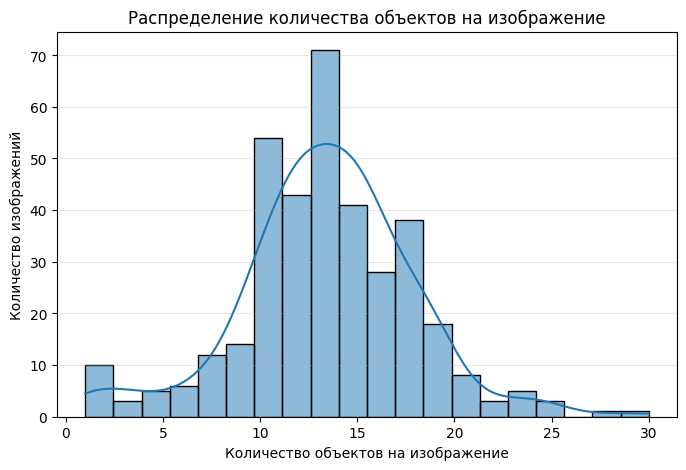

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(objects_per_image, bins=20, kde=True)
plt.title("Распределение количества объектов на изображение")
plt.xlabel("Количество объектов на изображение")
plt.ylabel("Количество изображений")
plt.grid(axis="y", alpha=0.3)
plt.show()

Большинство изображений содержит примерно от 10 до 18 объектов, при этом наиболее часто встречаются изображения с 13–14 объектами. Также присутствуют отдельные изображения с малым количеством объектов и изображения с большим числом объектов, достигающим примерно 25–30. Это показывает, что плотность объектов на изображениях неоднородна, поэтому при обучении модели детекции важно учитывать различное количество объектов в кадре

Размеры bounding box

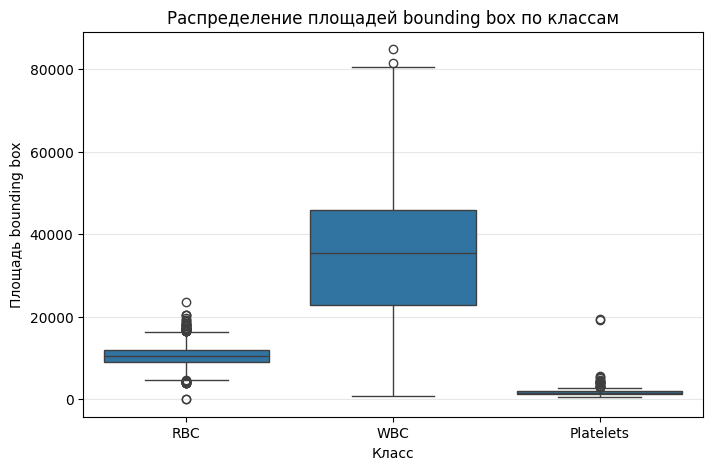

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="class_name",
    y="bbox_area"
)
plt.title("Распределение площадей bounding box по классам")
plt.xlabel("Класс")
plt.ylabel("Площадь bounding box")
plt.grid(axis="y", alpha=0.3)
plt.show()

Видно, что наибольшие площади ограничивающих рамок характерны для класса WBC. Это означает, что объекты данного класса занимают на изображениях более крупные области. Класс RBC имеет меньшие значения площади bounding box по сравнению с WBC, но существенно большие, чем Platelets. Класс Platelets характеризуется наименьшими площадями ограничивающих рамок

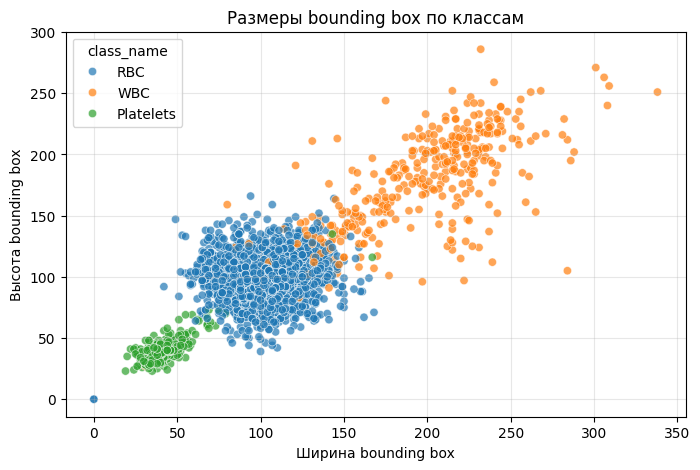

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="bbox_width",
    y="bbox_height",
    hue="class_name",
    alpha=0.7
)
plt.title("Размеры bounding box по классам")
plt.xlabel("Ширина bounding box")
plt.ylabel("Высота bounding box")
plt.grid(alpha=0.3)
plt.show()

In [15]:
def show_image_with_boxes(filename: str):
    image_path = IMAGES_DIR / filename
    image = Image.open(image_path)

    image_df = df[df["filename"] == filename]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)

    for _, row in image_df.iterrows():
        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["bbox_width"],
            row["bbox_height"],
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(
            row["xmin"],
            row["ymin"] - 5,
            row["class_name"],
            fontsize=10,
            color="red",
            bbox=dict(facecolor="white", alpha=0.7)
        )

    ax.set_title(f"Аннотации для изображения: {filename}")
    ax.axis("off")
    plt.show()

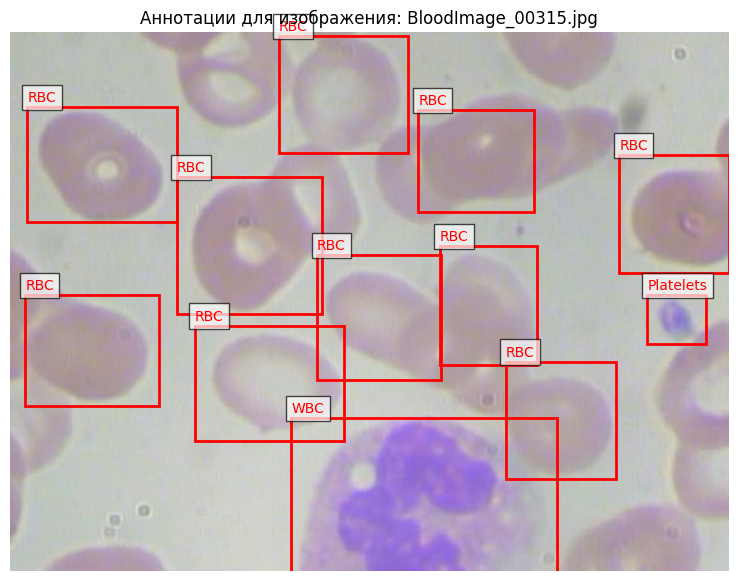

In [16]:
example_filename = df["filename"].iloc[0]
show_image_with_boxes(example_filename)

Несколько случайных изображений с разметкой

In [17]:
sample_files = df["filename"].drop_duplicates().sample(4, random_state=42).tolist()

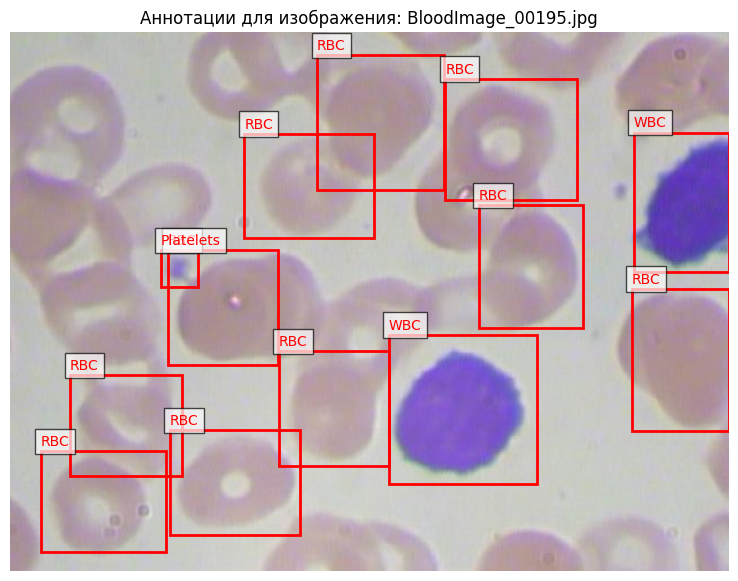

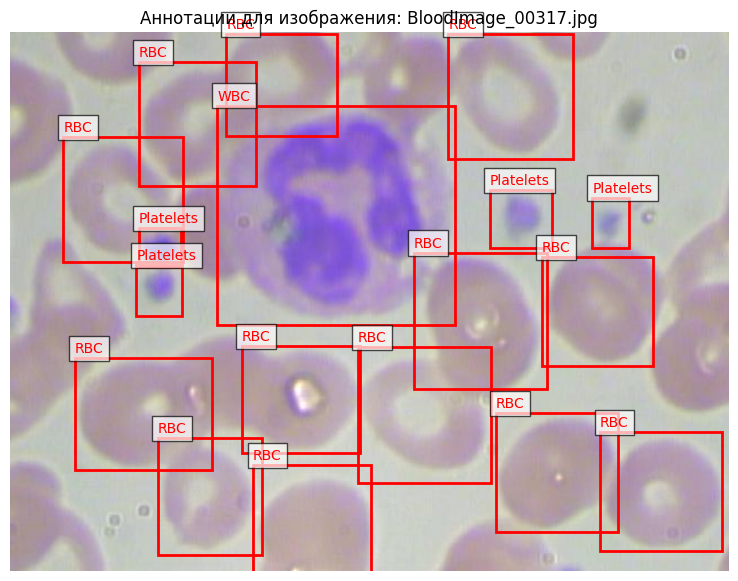

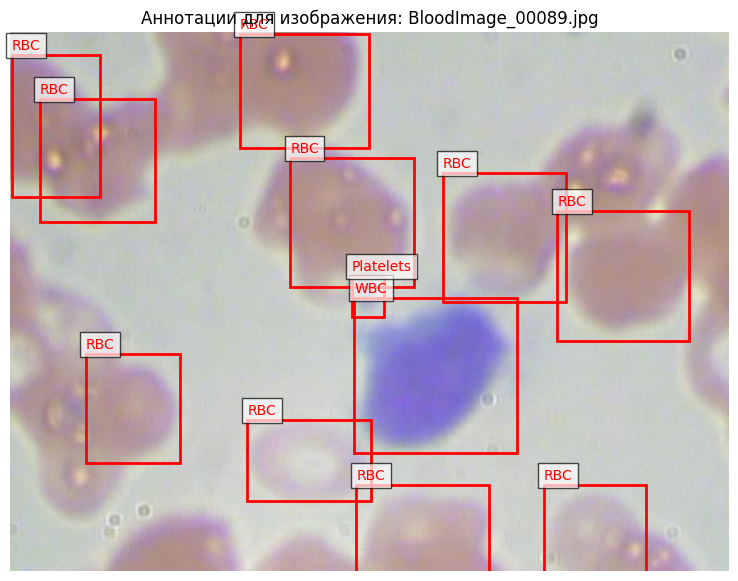

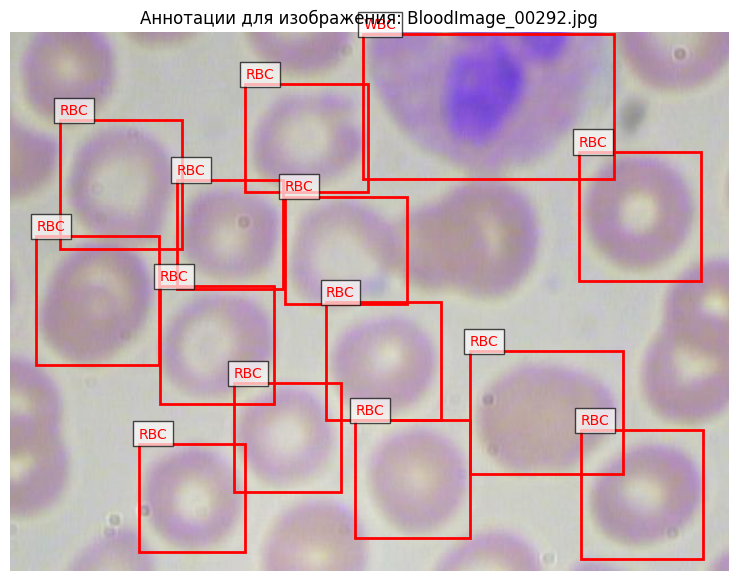

In [18]:
for filename in sample_files:
    show_image_with_boxes(filename)

Проверка размеров изображений

In [19]:
image_sizes = []

for image_file in IMAGES_DIR.glob("*.jpg"):
    with Image.open(image_file) as img:
        image_sizes.append({
            "filename": image_file.name,
            "width": img.width,
            "height": img.height
        })

sizes_df = pd.DataFrame(image_sizes)

sizes_df[["width", "height"]].value_counts()

width  height
640    480       364
Name: count, dtype: int64

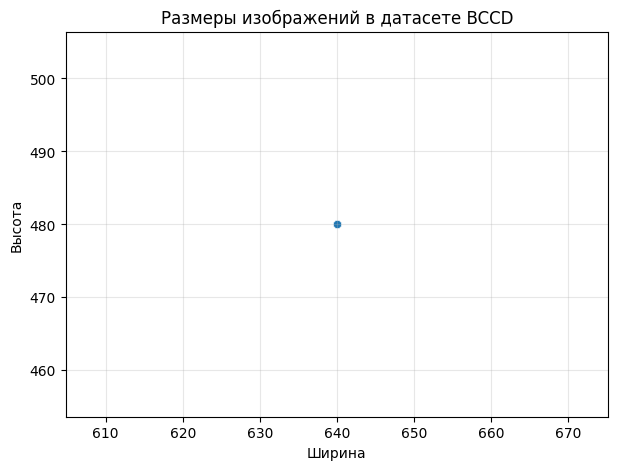

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=sizes_df,
    x="width",
    y="height"
)
plt.title("Размеры изображений в датасете BCCD")
plt.xlabel("Ширина")
plt.ylabel("Высота")
plt.grid(alpha=0.3)
plt.show()